In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('HRDataset_v14.csv', delimiter=',')
df.head(10)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,Brannon Miller,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,1/25/2019,0,4
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2/18/2019,0,16


In [ ]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("missing values per column")
print(missing_values)

missing values per column
DateofTermination    207
ManagerID              8
dtype: int64


In [13]:
anomalies = df[df['ManagerID'].isnull()]
print(anomalies[['Position', 'Department']])

                     Position         Department
19    Production Technician I  Production       
30   Production Technician II  Production       
44    Production Technician I  Production       
88   Production Technician II  Production       
135  Production Technician II  Production       
177  Production Technician II  Production       
232   Production Technician I  Production       
251   Production Technician I  Production       


In [20]:
product_list = df[
    ((df['Position'] == 'Production Technician I')) |
    ((df['Position'] == 'Production Technician II'))
]

print(product_list[['Position', 'Department', 'ManagerID']])

                     Position         Department  ManagerID
0     Production Technician I  Production              22.0
2    Production Technician II  Production              20.0
3     Production Technician I  Production              16.0
4     Production Technician I  Production              39.0
5     Production Technician I  Production              11.0
..                        ...                ...        ...
304  Production Technician II  Production              12.0
305  Production Technician II  Production              14.0
306  Production Technician II  Production              20.0
307   Production Technician I  Production              12.0
310   Production Technician I  Production              14.0

[194 rows x 3 columns]


In [15]:
print("Shape of DataFrame:", df.shape)
print("Columns in DataFrame:", df.columns.to_list())
print("Data types of columns:", df.dtypes)
   
print("Information about DataFrame:")
df.info()
  
print("Number of unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Shape of DataFrame: (311, 37)
Columns in DataFrame: ['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences', 'Termd_Label']
Data types of columns: Employee_Name                  object
EmpID                           int64
MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary               

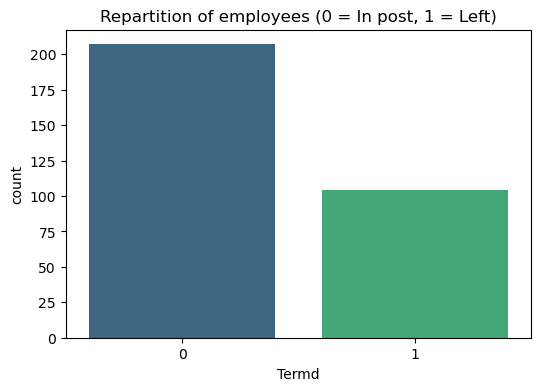

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Termd', palette='viridis')
plt.title("Repartition of employees (0 = In post, 1 = Left)")
plt.show()

In [4]:
# 1. Numerical summary
print(df.describe().round(2))

# 2. Categorical summary
print()
print(df.describe(include=['O']))

          EmpID  MarriedID  MaritalStatusID  GenderID  EmpStatusID  DeptID  \
count    311.00     311.00           311.00    311.00       311.00  311.00   
mean   10156.00       0.40             0.81      0.43         2.39    4.61   
std       89.92       0.49             0.94      0.50         1.79    1.08   
min    10001.00       0.00             0.00      0.00         1.00    1.00   
25%    10078.50       0.00             0.00      0.00         1.00    5.00   
50%    10156.00       0.00             1.00      0.00         1.00    5.00   
75%    10233.50       1.00             1.00      1.00         5.00    5.00   
max    10311.00       1.00             4.00      1.00         5.00    6.00   

       PerfScoreID  FromDiversityJobFairID     Salary   Termd  PositionID  \
count       311.00                  311.00     311.00  311.00      311.00   
mean          2.98                    0.09   69020.68    0.33       16.85   
std           0.59                    0.29   25156.64    0.47     

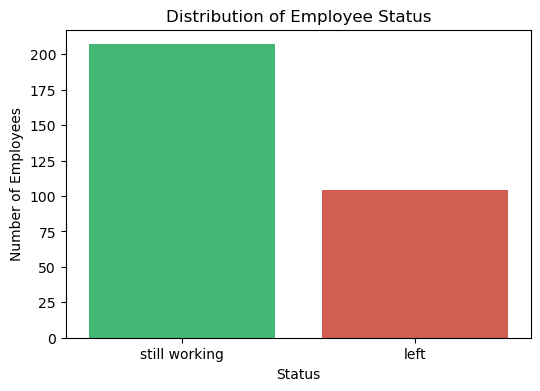

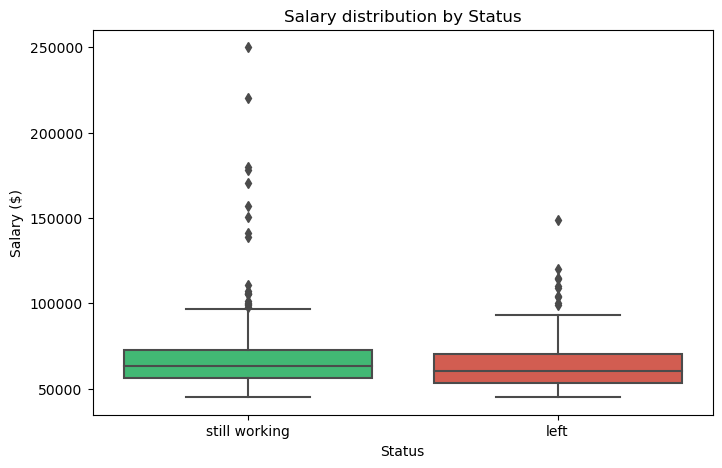

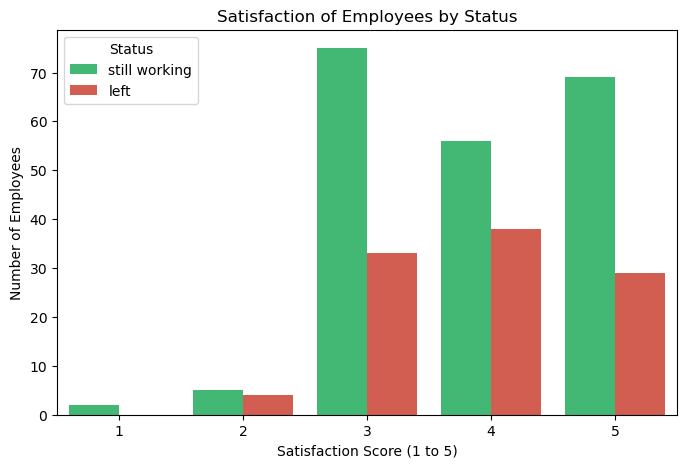

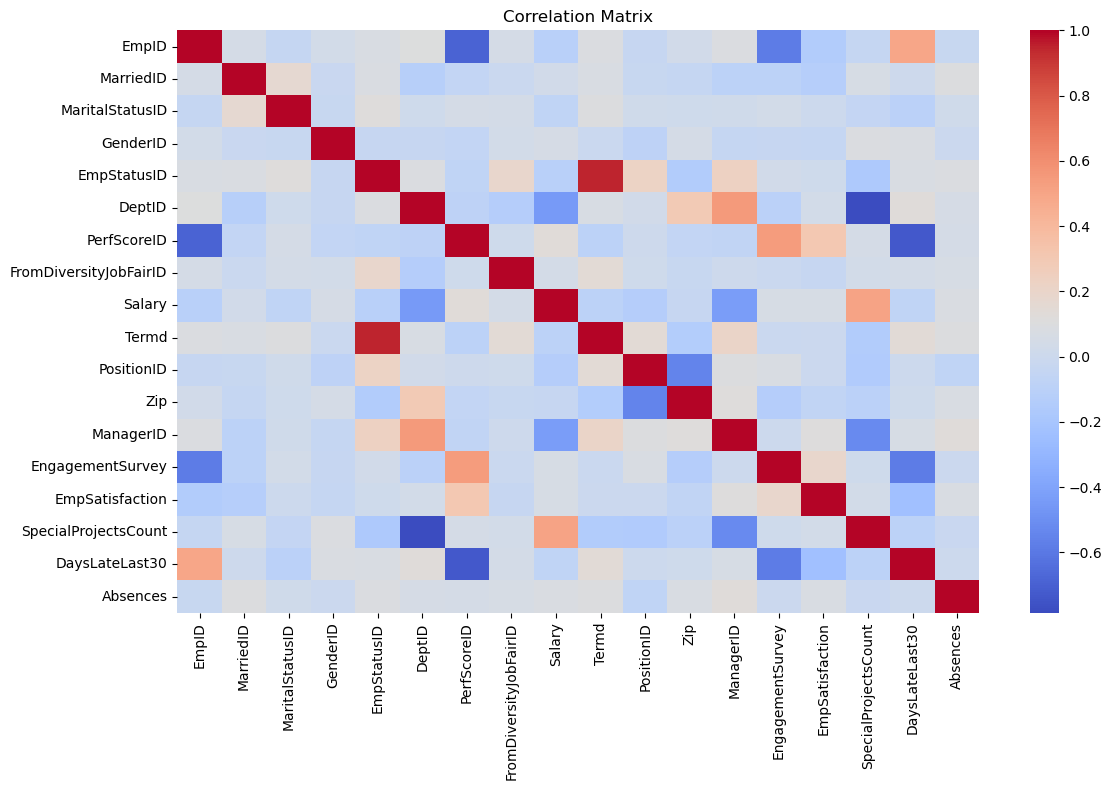

In [ ]:
df['Termd_Label'] = df['Termd'].replace({0: 'still working', 1: 'left'})

# Colors definition for the plots
colors = {'still working': '#2ecc71', 'left': '#e74c3c'}

# Graph 1! Distribution of Employee Status (Termd)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Termd_Label', palette=colors, order=['still working', 'left'])
plt.title("Distribution of Employee Status")
plt.xlabel("Status")
plt.ylabel("Number of Employees")
plt.show()

# Graph 2: Salary distribution by Status (Termd)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Termd_Label', y='Salary', palette=colors, order=['still working', 'left'])
plt.title("Salary distribution by Status")
plt.xlabel("Status")
plt.ylabel("Salary ($)")
plt.show()

#5. Employee Satisfaction distribution by Status (Termd)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='EmpSatisfaction', hue='Termd_Label', palette=colors, hue_order=['still working', 'left'])
plt.title("Satisfaction of Employees by Status")
plt.xlabel("Satisfaction Score (1 to 5)")
plt.ylabel("Number of Employees")
plt.legend(title='Status')
plt.show()

# 6. Correlation matrix (numeric only)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

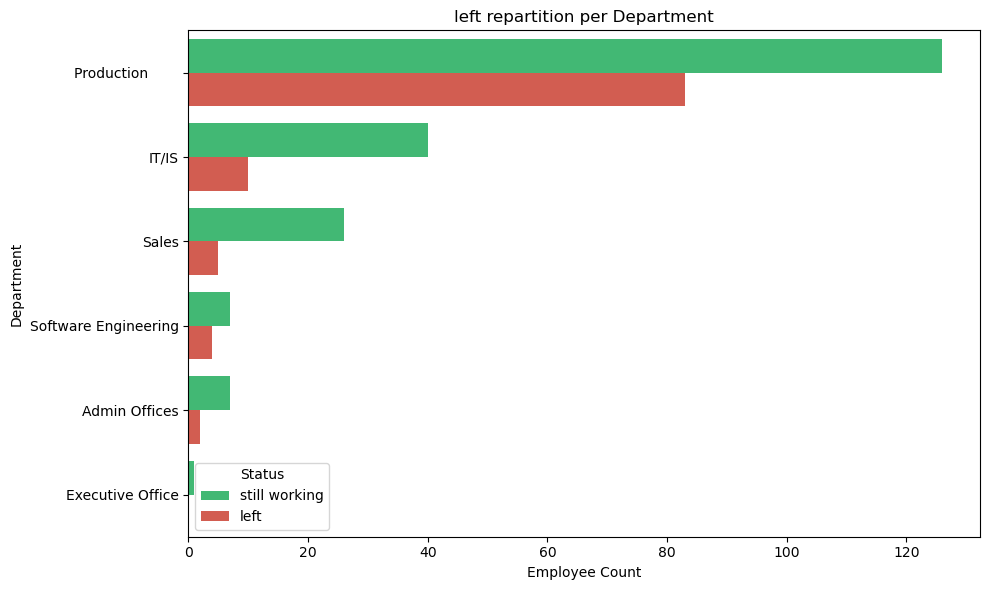

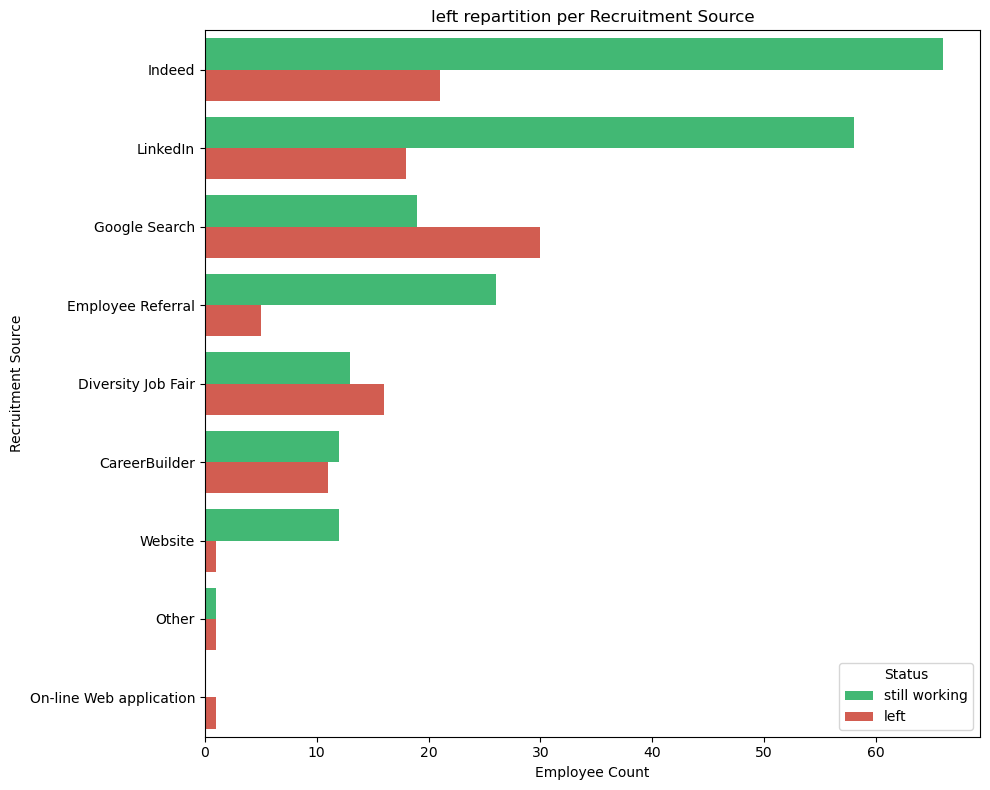

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Department', hue='Termd_Label', 
              palette={'still working': '#2ecc71', 'left': '#e74c3c'}, 
              hue_order=['still working', 'left'],
              order=df['Department'].value_counts().index)
plt.title("left repartition per Department")
plt.xlabel("Employee Count")
plt.ylabel("Department")
plt.legend(title='Status')
plt.tight_layout()
plt.show()

# Also doing one for RecruitmentSource as it's interesting
plt.figure(figsize=(10, 8))
sns.countplot(data=df, y='RecruitmentSource', hue='Termd_Label', 
              palette={'still working': '#2ecc71', 'left': '#e74c3c'}, 
              hue_order=['still working', 'left'],
              order=df['RecruitmentSource'].value_counts().index)
plt.title("left repartition per Recruitment Source")
plt.xlabel("Employee Count")
plt.ylabel("Recruitment Source")
plt.legend(title='Status')
plt.tight_layout()
plt.show()


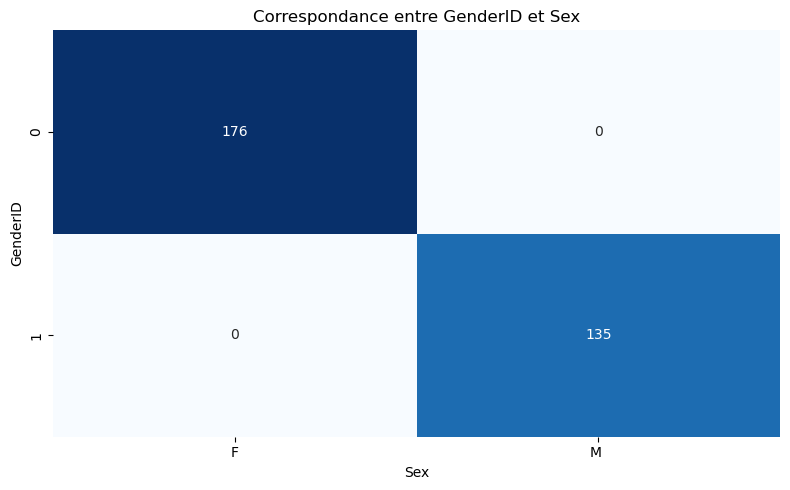

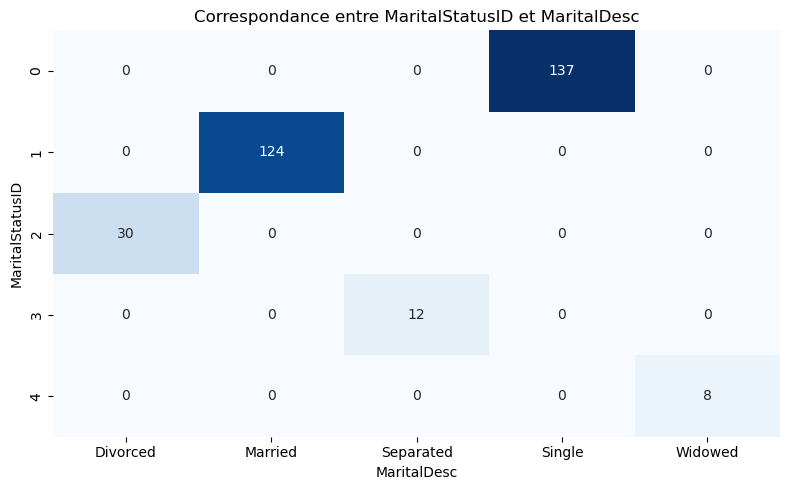

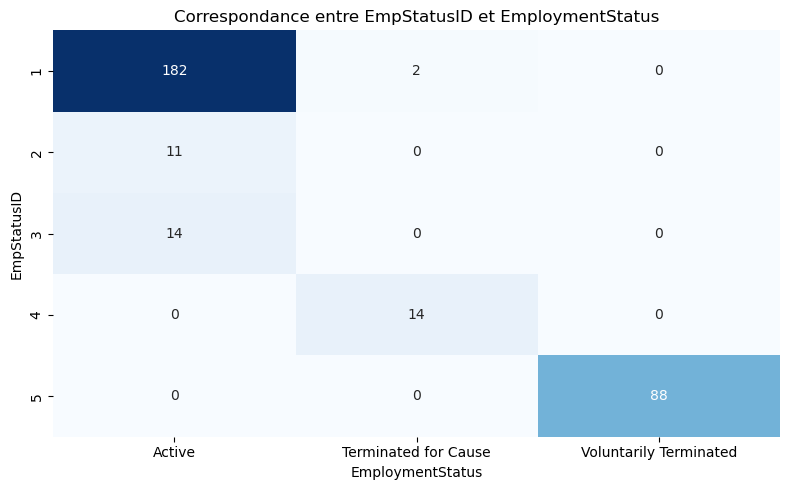

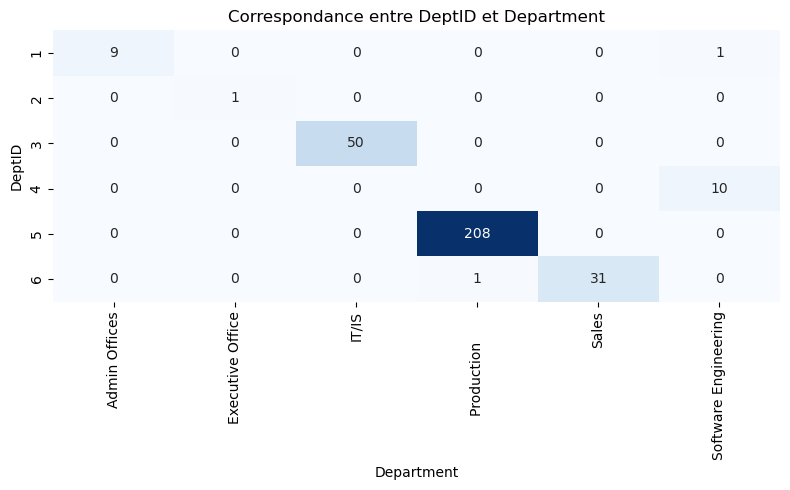

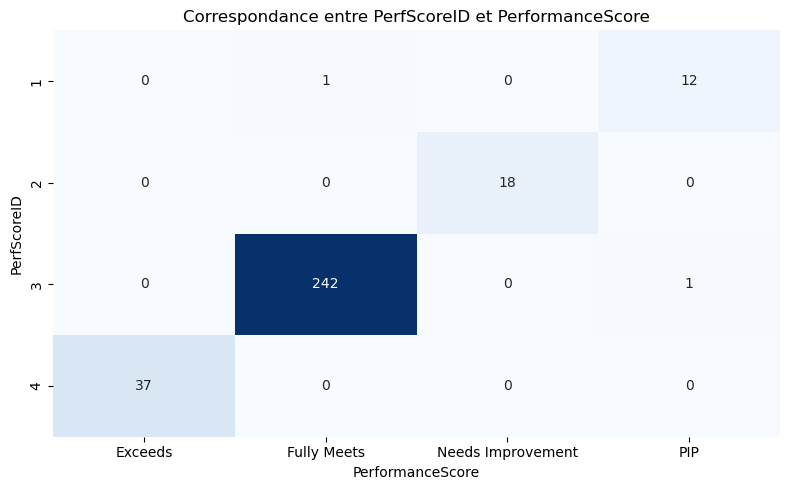

In [7]:
pairs = [
    ('GenderID', 'Sex'),
    ('MaritalStatusID', 'MaritalDesc'),
    ('EmpStatusID', 'EmploymentStatus'),
    ('DeptID', 'Department'),
    ('PerfScoreID', 'PerformanceScore')
]

for id_col, txt_col in pairs:
    plt.figure(figsize=(8, 5))
    ct = pd.crosstab(df[id_col], df[txt_col])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Correspondance entre {id_col} et {txt_col}")
    plt.ylabel(id_col)
    plt.xlabel(txt_col)
    plt.tight_layout()
    plt.show()

Based on the plots before, we show the lines where we have the problem 

In [14]:
# Identification des anomalies basées sur notre analyse précédente
anomalies = df[
    ((df['PerfScoreID'] == 1) & (df['PerformanceScore'] == 'Fully Meets')) |
    ((df['DeptID'] == 1) & (df['Department'] == 'Software Engineering')) |
    ((df['DeptID'] == 6) & (df['Department'] == 'Production'))
]

print("Lines with ID/Text inconsistencies:")
print(anomalies[['Employee_Name', 'EmpStatusID', 'EmploymentStatus', 'PerfScoreID', 'PerformanceScore', 'DeptID', 'Department', 'Termd', 'DateofTermination', 'DateofHire']])

Lines with ID/Text inconsistencies:
    Employee_Name  EmpStatusID        EmploymentStatus  PerfScoreID  \
64     Dee, Randy            1                  Active            1   
227   Quinn, Sean            5  Voluntarily Terminated            3   

    PerformanceScore  DeptID            Department  Termd DateofTermination  \
64       Fully Meets       6     Production             0               NaN   
227      Fully Meets       1  Software Engineering      1         8/15/2015   

    DateofHire  
64    7/9/2018  
227  2/21/2011  


We observed that we can merge genderID and sex together, MaritalStatusId and MartialDesc together, DeptId and Department together, and PerfScoreId and PerformanceScore together. We have only 2 cases which doesn't follow the logic. One was terminated in 2015 and one still active, hired in 2018.

In [16]:
# Convert date columns to datetime
date_cols = ['DateofHire', 'DateofTermination', 'LastPerformanceReview_Date', 'DOB']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Find the maximum date in the dataset to establish the "snapshot date"
max_hire = df['DateofHire'].max()
max_term = df['DateofTermination'].max()
max_review = df['LastPerformanceReview_Date'].max()

print(f"Max Hire Date: {max_hire}")
print(f"Max Termination Date: {max_term}")
print(f"Max Review Date: {max_review}")

snapshot_date = max(max_hire, max_term, max_review)
print(f"Inferred Snapshot Date: {snapshot_date}")

Max Hire Date: 2018-07-09 00:00:00
Max Termination Date: 2018-11-10 00:00:00
Max Review Date: 2019-02-28 00:00:00
Inferred Snapshot Date: 2019-02-28 00:00:00


C:\Users\coste\AppData\Local\Temp\ipykernel_14944\65313940.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


The latest review date is 2019-02-28. We then set today as 2019-02-28. We will create time of stay which is date of termination - date of hire for employees who left and today - date of hire for the ones still working.

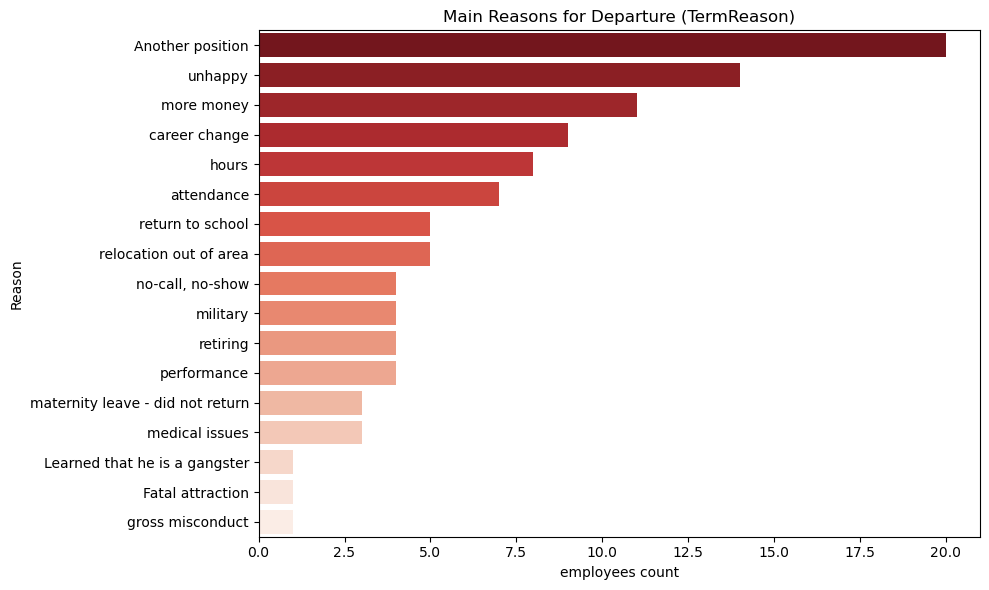

In [22]:
plt.figure(figsize=(10, 6))

term_reasons = df[df['Termd'] == 1]['TermReason'].value_counts()

sns.barplot(y=term_reasons.index, x=term_reasons.values, palette='Reds_r')
plt.title("Main Reasons for Departure (TermReason)")
plt.xlabel("employees count")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

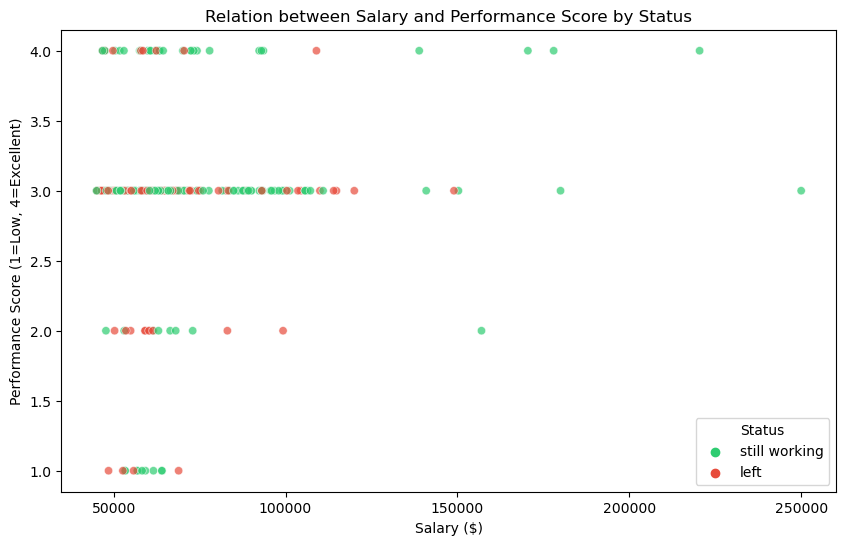

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Salary', y='PerfScoreID', hue='Termd_Label', palette=couleurs, alpha=0.7)
plt.title("Relation between Salary and Performance Score by Status")
plt.xlabel("Salary ($)")
plt.ylabel("Performance Score (1=Low, 4=Excellent)")
plt.legend(title='Status')
plt.show()